In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_9.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.04279213237884853, 0.9873142857142857)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.2989324115470052, 0.9124)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

airplane      0.977064
automobile    0.997410
bird          0.984090
cat           0.976484
deer          0.992588
dog           0.974542
frog          0.996879
horse         0.990294
ship          0.988196
truck         0.995434
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(5).index.map(trainset.dataset.classess)]
targetF

[5, 3, 0, 2, 8]

In [17]:
targetF=[0,1,8,9]

In [18]:
 #將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                     

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t==0):
                            indexT.append(idx.cpu().numpy().item()) 
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                    

            torch.cuda.empty_cache() 
        return indexF,indexT

In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(14025, 24463)

In [20]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4006, 6987)

In [21]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                if(t!=0):
                    flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                    flat_data.append(d.cpu().numpy()) 
                
    return flat_data,flat_true

In [22]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [24]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision" or data_name=='T' or data_name=='F'):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.0008604584175797811,train_accu=0.9998095963442498
Epoch=0,valid_loss=0.028956620459839155,valid_accu=0.993338514488731
0
Epoch=1,train_loss=0.0005052368745057779,train_accu=0.9998413302868748
Epoch=1,valid_loss=0.028160391827455764,valid_accu=0.9936715887642944
0
Epoch=2,train_loss=0.0004146189462043081,train_accu=0.9998413302868748
Epoch=2,valid_loss=0.03276045002052534,valid_accu=0.9915621183523926
Epoch=3,train_loss=0.00010115072171849751,train_accu=0.999968266057375
Epoch=3,valid_loss=0.032695388502854965,valid_accu=0.994115687798379
0
Epoch=4,train_loss=7.251528578639863e-05,train_accu=0.999968266057375
Epoch=4,valid_loss=0.03215857899394482,valid_accu=0.9936715887642944
Epoch=5,train_loss=0.00012491688090213816,train_accu=0.9999047981721249
Epoch=5,valid_loss=0.04318082880166254,valid_accu=0.9934495392472521
Epoch=6,train_loss=0.0001729787809163559,train_accu=0.99993653211475
Epoch=6,valid_loss=0.048744076586830894,valid_accu=0.9925613411790829
Epoch=7,train_

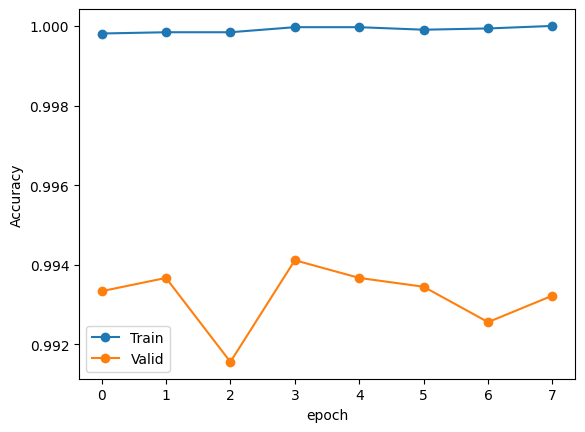

In [25]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [26]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.028452540520903537,train_accu=0.9920696562155091
Epoch=0,valid_loss=0.305925411175052,valid_accu=0.9118362673536567
0
Epoch=1,train_loss=0.016667764433589943,train_accu=0.9955034133180722
Epoch=1,valid_loss=0.3456657042110258,valid_accu=0.9115500214684414
Epoch=2,train_loss=0.01517625384033954,train_accu=0.9957486816825409
Epoch=2,valid_loss=0.37396393453893473,valid_accu=0.9085444396736797
Epoch=3,train_loss=0.011912878810692236,train_accu=0.9969341454441402
Epoch=3,valid_loss=0.38418903722463377,valid_accu=0.9075425790754258
Epoch=4,train_loss=0.005860194041535006,train_accu=0.9985283898131873
Epoch=4,valid_loss=0.404348091973722,valid_accu=0.9132674967797338
0
Epoch=5,train_loss=0.004371609959552886,train_accu=0.9990189265421249
Epoch=5,valid_loss=0.39850725775046875,valid_accu=0.9122656361814799
Epoch=6,train_loss=0.0038919086656029316,train_accu=0.9992641949065937
Epoch=6,valid_loss=0.4422741299797677,valid_accu=0.9073994561328181
Epoch=7,train_loss=0.00224465

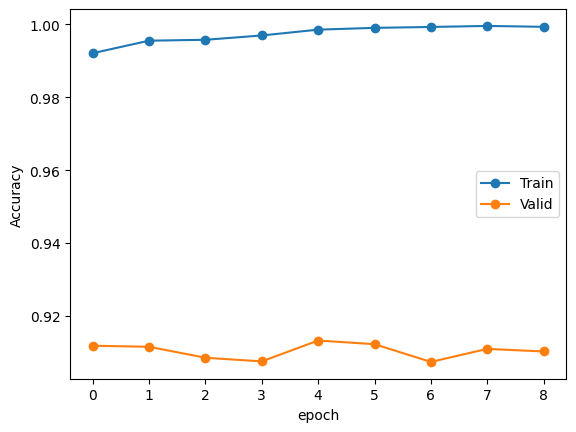

In [27]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [28]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.013867704107827093,train_accu=0.9955793226381462
Epoch=0,valid_loss=0.1792814516586996,valid_accu=0.9515726410384423
0
Epoch=1,train_loss=0.006402990275615178,train_accu=0.9977896613190731
Epoch=1,valid_loss=0.172332855732122,valid_accu=0.9583125312031953
0
Epoch=2,train_loss=0.006201420994997381,train_accu=0.9979322638146167
Epoch=2,valid_loss=0.20123563075558568,valid_accu=0.9565651522715926
Epoch=3,train_loss=0.005270289143144397,train_accu=0.9981461675579323
Epoch=3,valid_loss=0.21013822838047339,valid_accu=0.9518222666000998
Epoch=4,train_loss=0.0026315961200156822,train_accu=0.9994295900178253
Epoch=4,valid_loss=0.2012417533787893,valid_accu=0.9588117823265102
0
Epoch=5,train_loss=0.002378691735628863,train_accu=0.9994295900178253
Epoch=5,valid_loss=0.20233225622089998,valid_accu=0.9578132800798802
Epoch=6,train_loss=0.0019604092335933545,train_accu=0.9995721925133689
Epoch=6,valid_loss=0.21364183373990717,valid_accu=0.9560659011482776
Epoch=7,train_loss=0.00

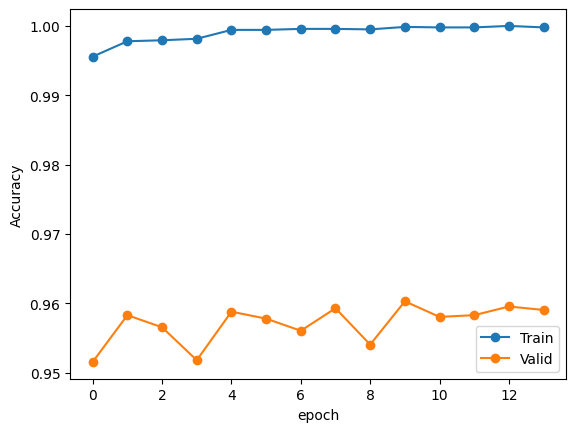

In [29]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [30]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.00010115072171849751, 0.999968266057375)

In [31]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.032695388502854965, 0.994115687798379)

In [32]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.006065554243326819, 0.9984466336916976)

In [33]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.0006340326290827439, 0.9999286987522281)

In [34]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.3943858579255953, 0.9121225132388722)

In [35]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.23105833402665005, 0.9620569146280579)

In [36]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.004210022571096488, 0.999, 14025)

In [37]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.36444684757329526, 0.9281, 4006)

In [38]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.013285660627430168, 0.9981142857142857, 12081, 22919)

In [39]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.43323373969867823, 0.9205, 3471, 6529)

In [40]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [41]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.042792,0.987314,0.298932,0.912400
1,Model_Decision,0.000101,0.999968,0.032695,0.994116
2,Model_T,0.006066,0.998447,0.394386,0.912123
3,Model_F,0.000634,0.999929,0.231058,0.962057
4,Total_Model,0.013286,0.998114,0.433234,0.920500
5,Total_Model_without_decision,0.004210,0.999000,0.364447,0.928100


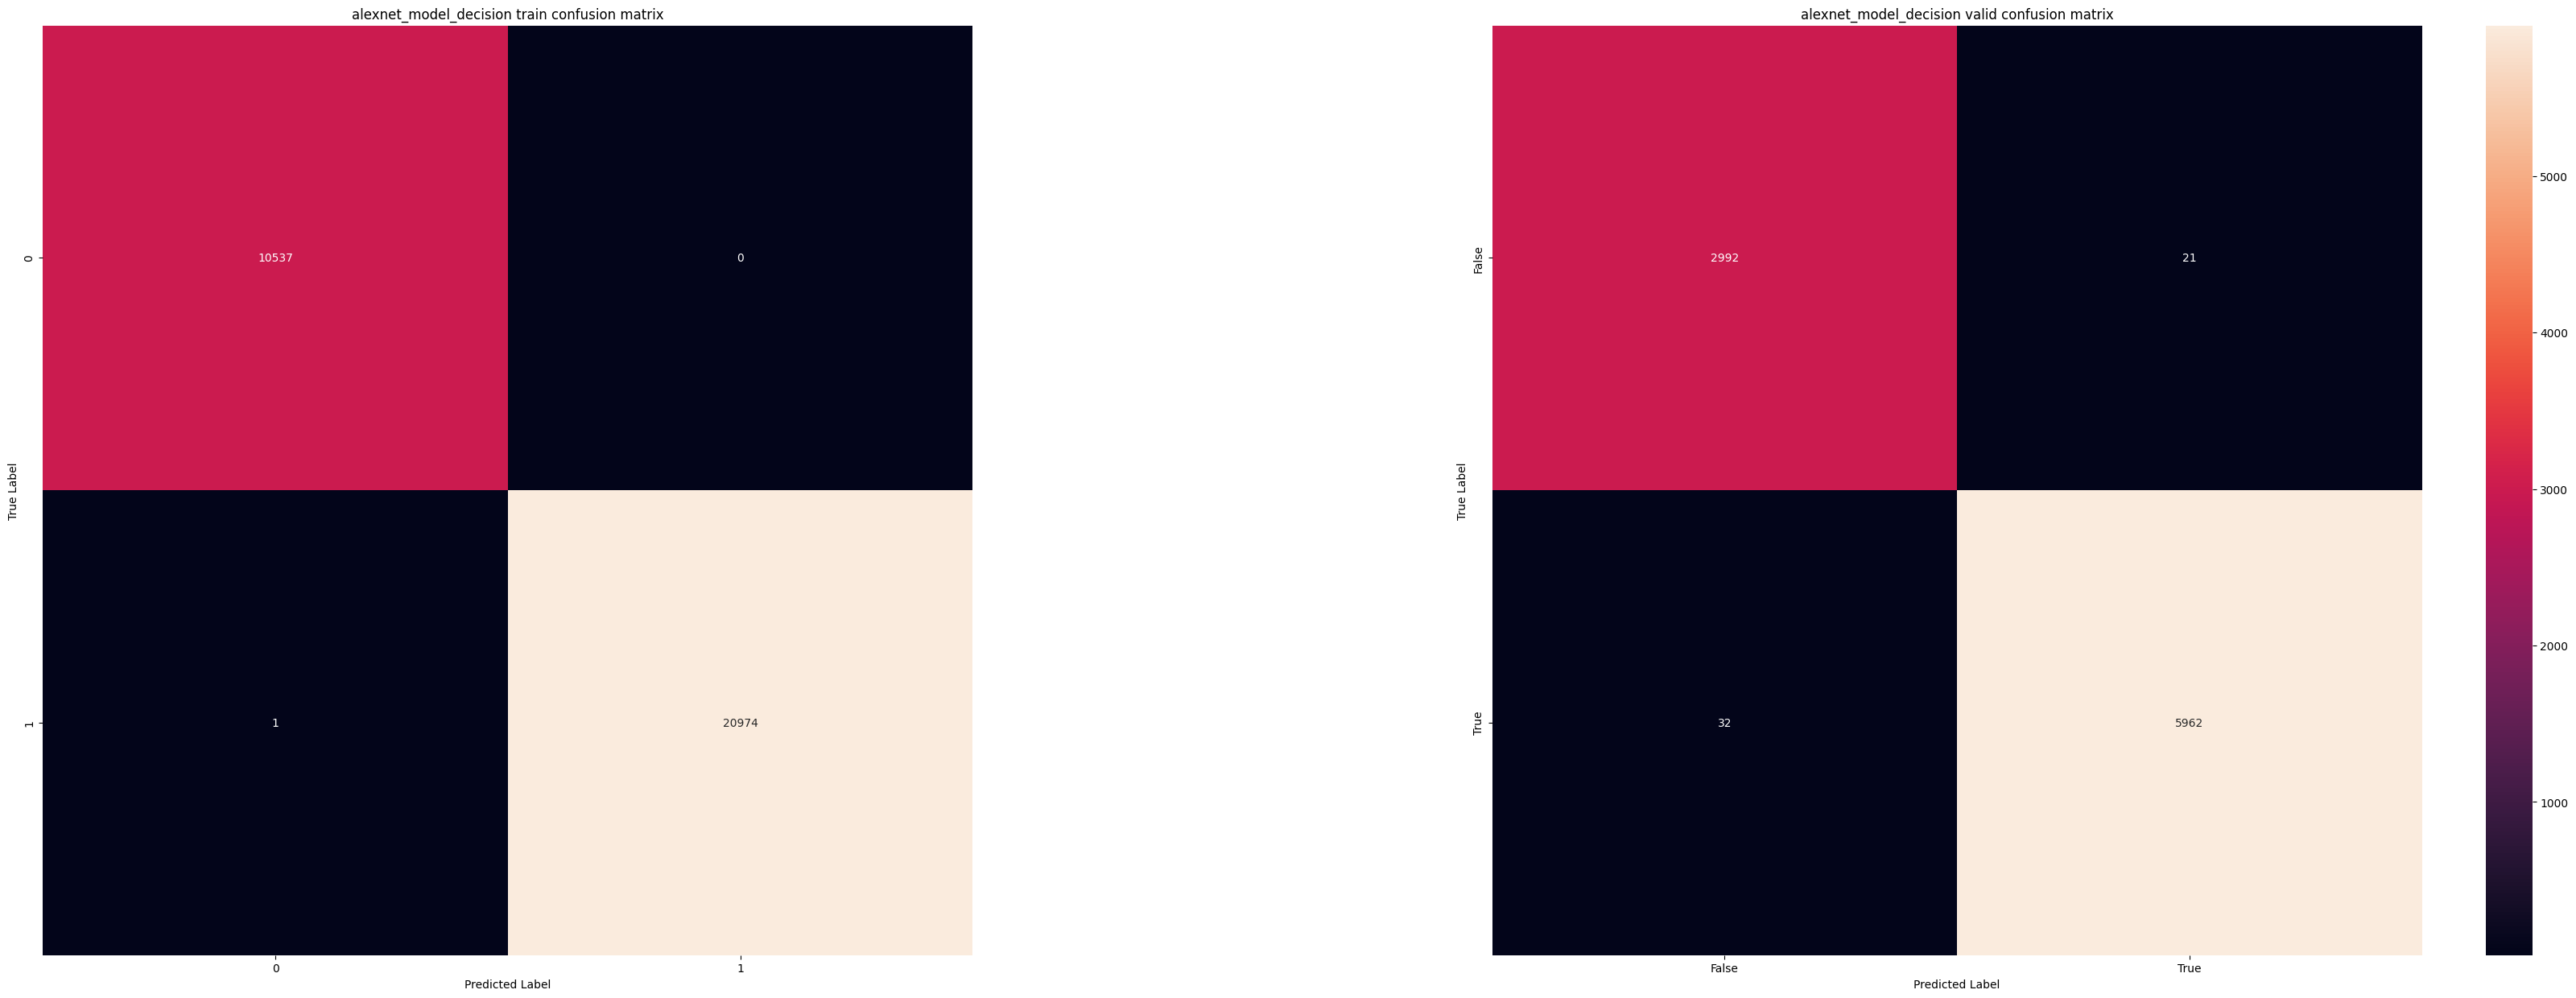

In [42]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

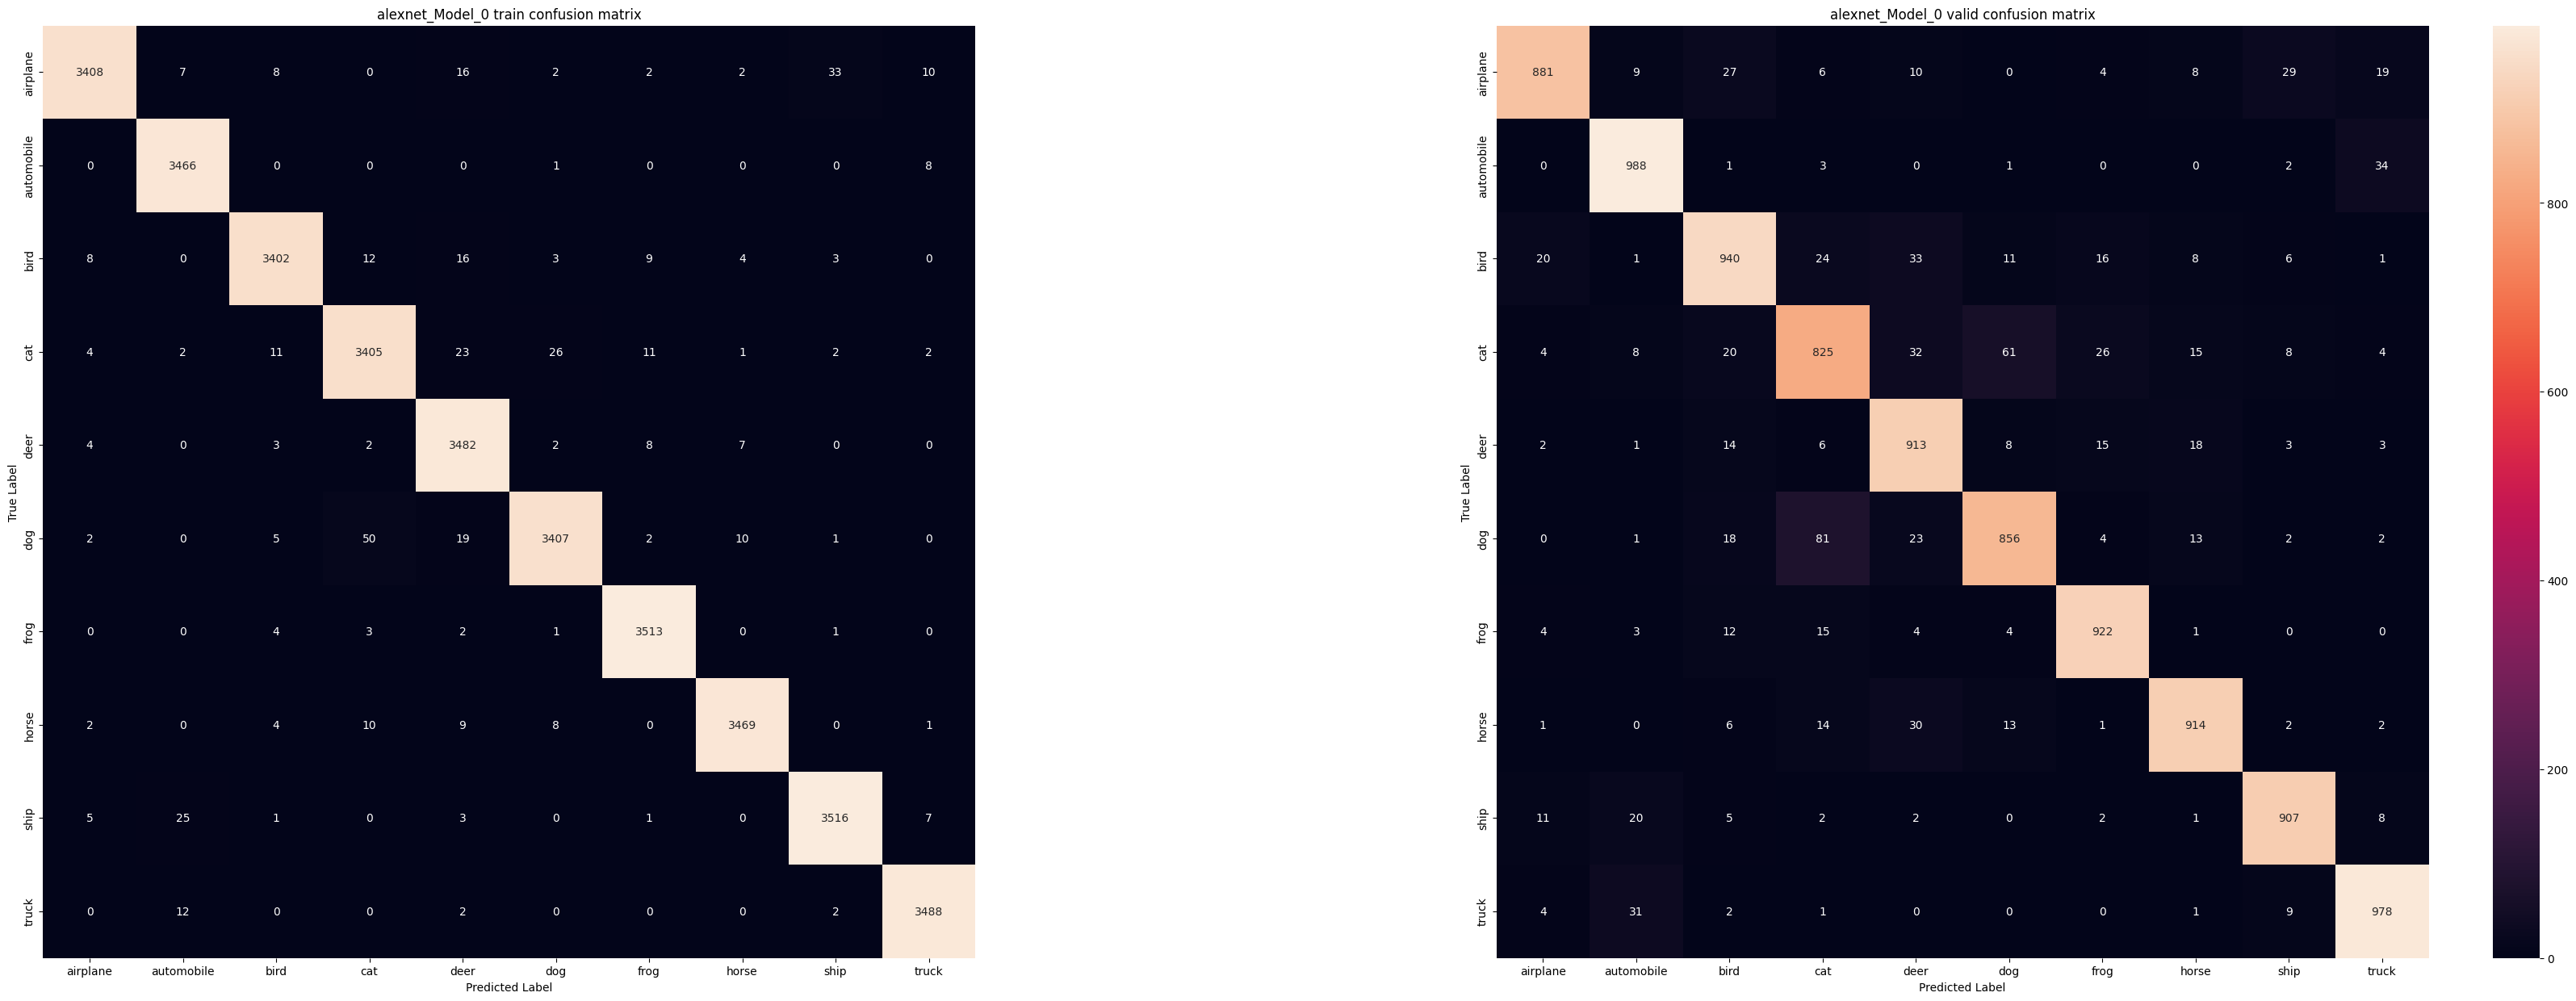

In [43]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [44]:
n_classes = confusion_matrix_train.shape[0]
confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
for i in range(n_classes):
    for j in range(n_classes):
        if i != j:
            degree = (confusion_matrix_train.iloc[i, j] / np.sum(confusion_matrix_train.iloc[i])) + \
                     (confusion_matrix_train.iloc[j, i] / np.sum(confusion_matrix_train.iloc[j]))
            confusion_degrees[i, j] = degree
N = 7
# 只检查下三角的元素
indices = np.tril_indices_from(confusion_degrees, k=-1)
flat_indices = np.argsort(confusion_degrees[indices])[-N:]
row_indices = indices[0][flat_indices]
col_indices = indices[1][flat_indices]

print("Top", N, "Elements:")
print(confusion_degrees[row_indices, col_indices])
print("Top", N, "Positions:")
print(' ',row_indices,'\n', col_indices)

Top 7 Elements:
[0.00572741 0.00600491 0.00662579 0.00702642 0.00716605 0.01086629
 0.02175833]
Top 7 Positions:
  [4 5 3 8 4 8 5] 
 [0 4 2 1 3 0 3]


In [45]:
n_classes = confusion_matrix_valid.shape[0]
confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
for i in range(n_classes):
    for j in range(n_classes):
        if i != j:
            degree = (confusion_matrix_total_train.iloc[i, j] / np.sum(confusion_matrix_total_train.iloc[i])) + \
                     (confusion_matrix_total_train.iloc[j, i] / np.sum(confusion_matrix_total_train.iloc[j]))
            confusion_degrees[i, j] = degree
            
N = 4
# 只检查下三角的元素
indices = np.tril_indices_from(confusion_degrees, k=-1)
flat_indices = np.argsort(confusion_degrees[indices])[-N:]
row_indices = indices[0][flat_indices]
col_indices = indices[1][flat_indices]

print("Top", N, "Elements:")
print(confusion_degrees[row_indices, col_indices])
print("Top", N, "Positions:")
print(' ',row_indices,'\n', col_indices)

Top 4 Elements:
[0.00086458 0.0011418  0.00115193 0.004298  ]
Top 4 Positions:
  [5 9 2 5] 
 [2 7 0 3]


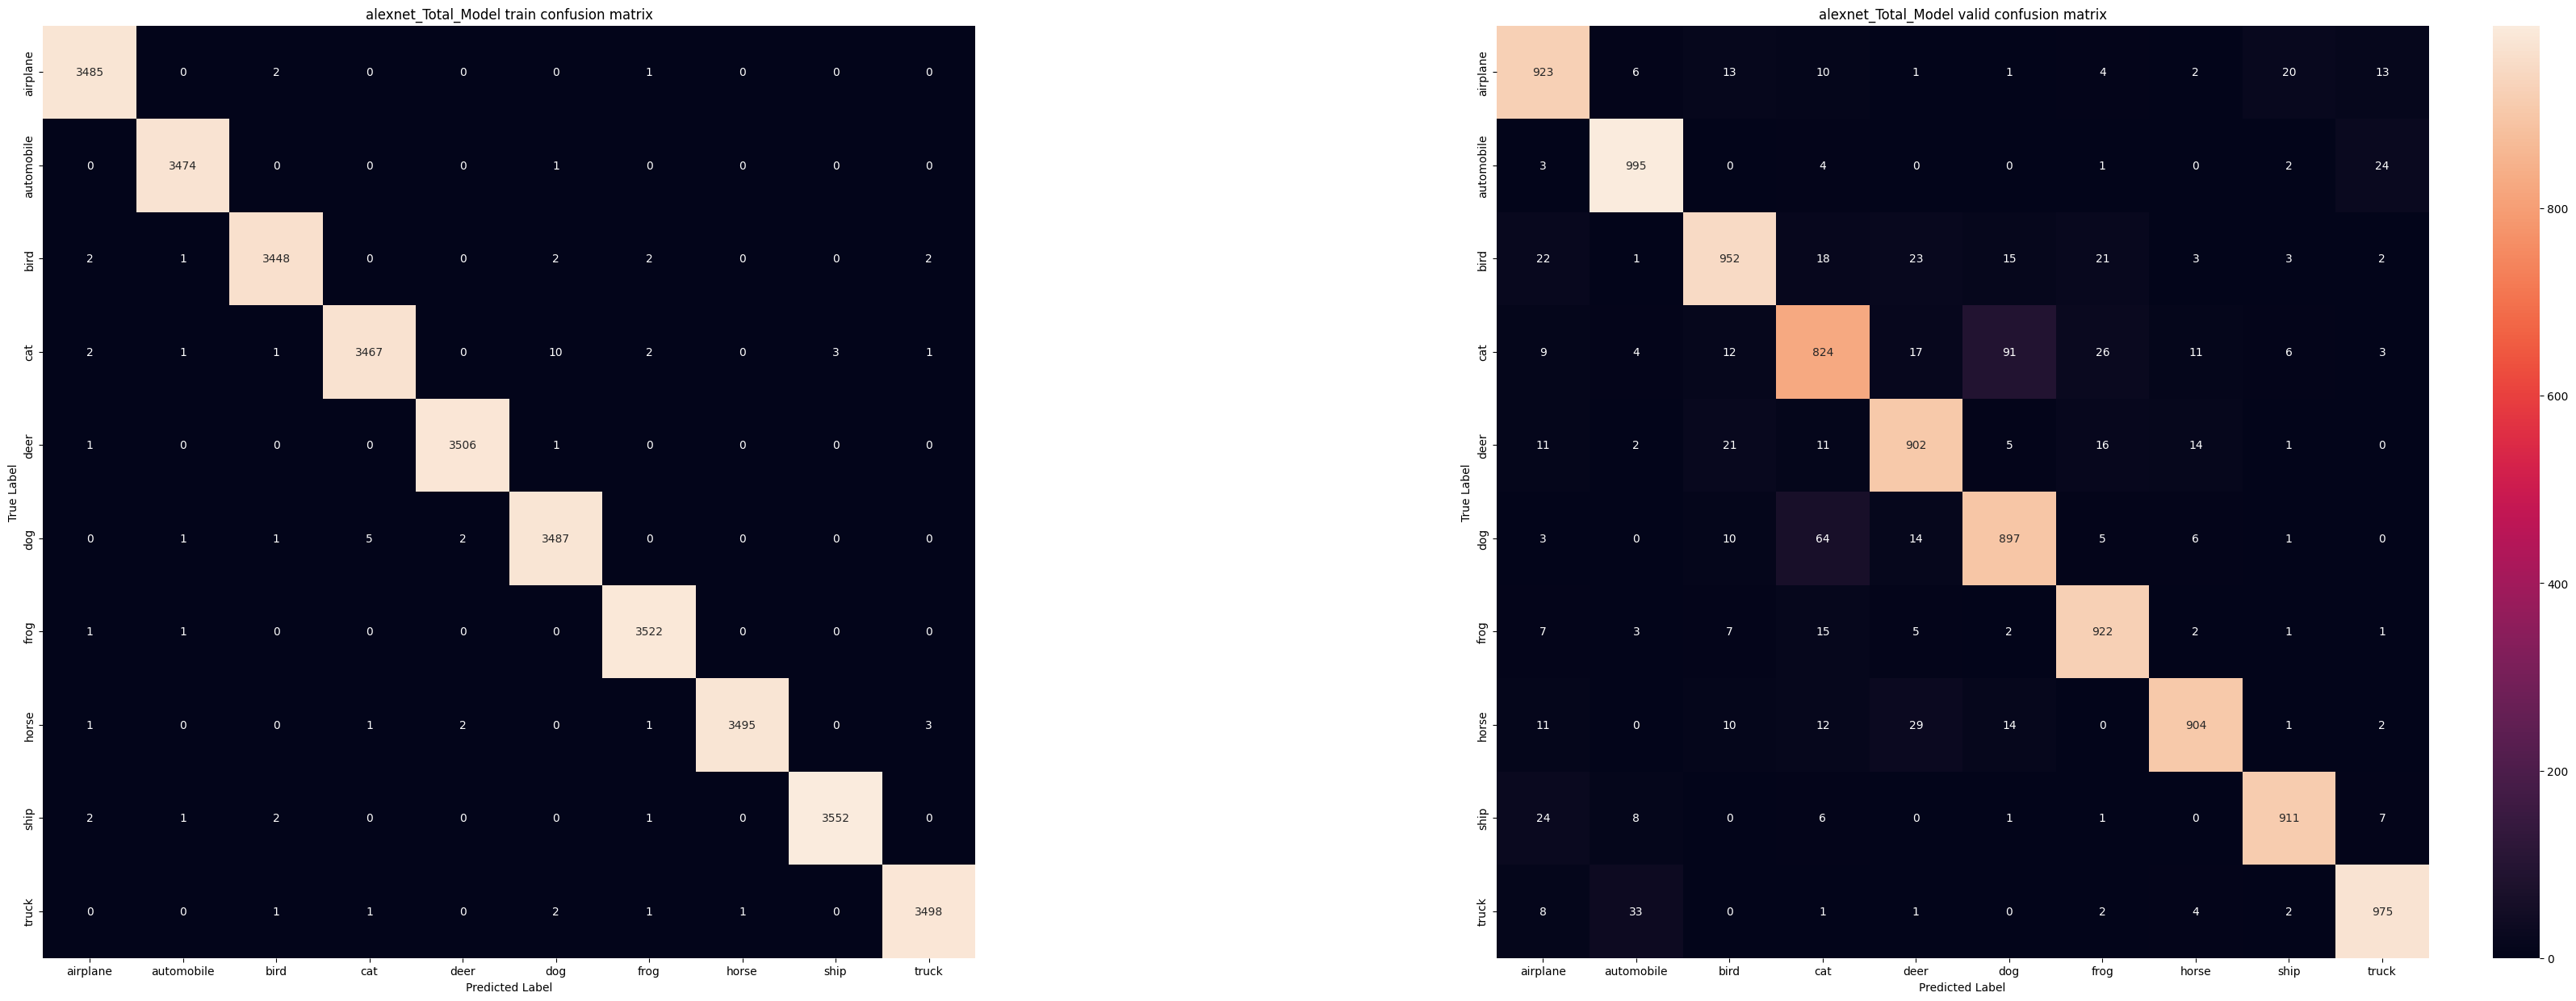

In [46]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

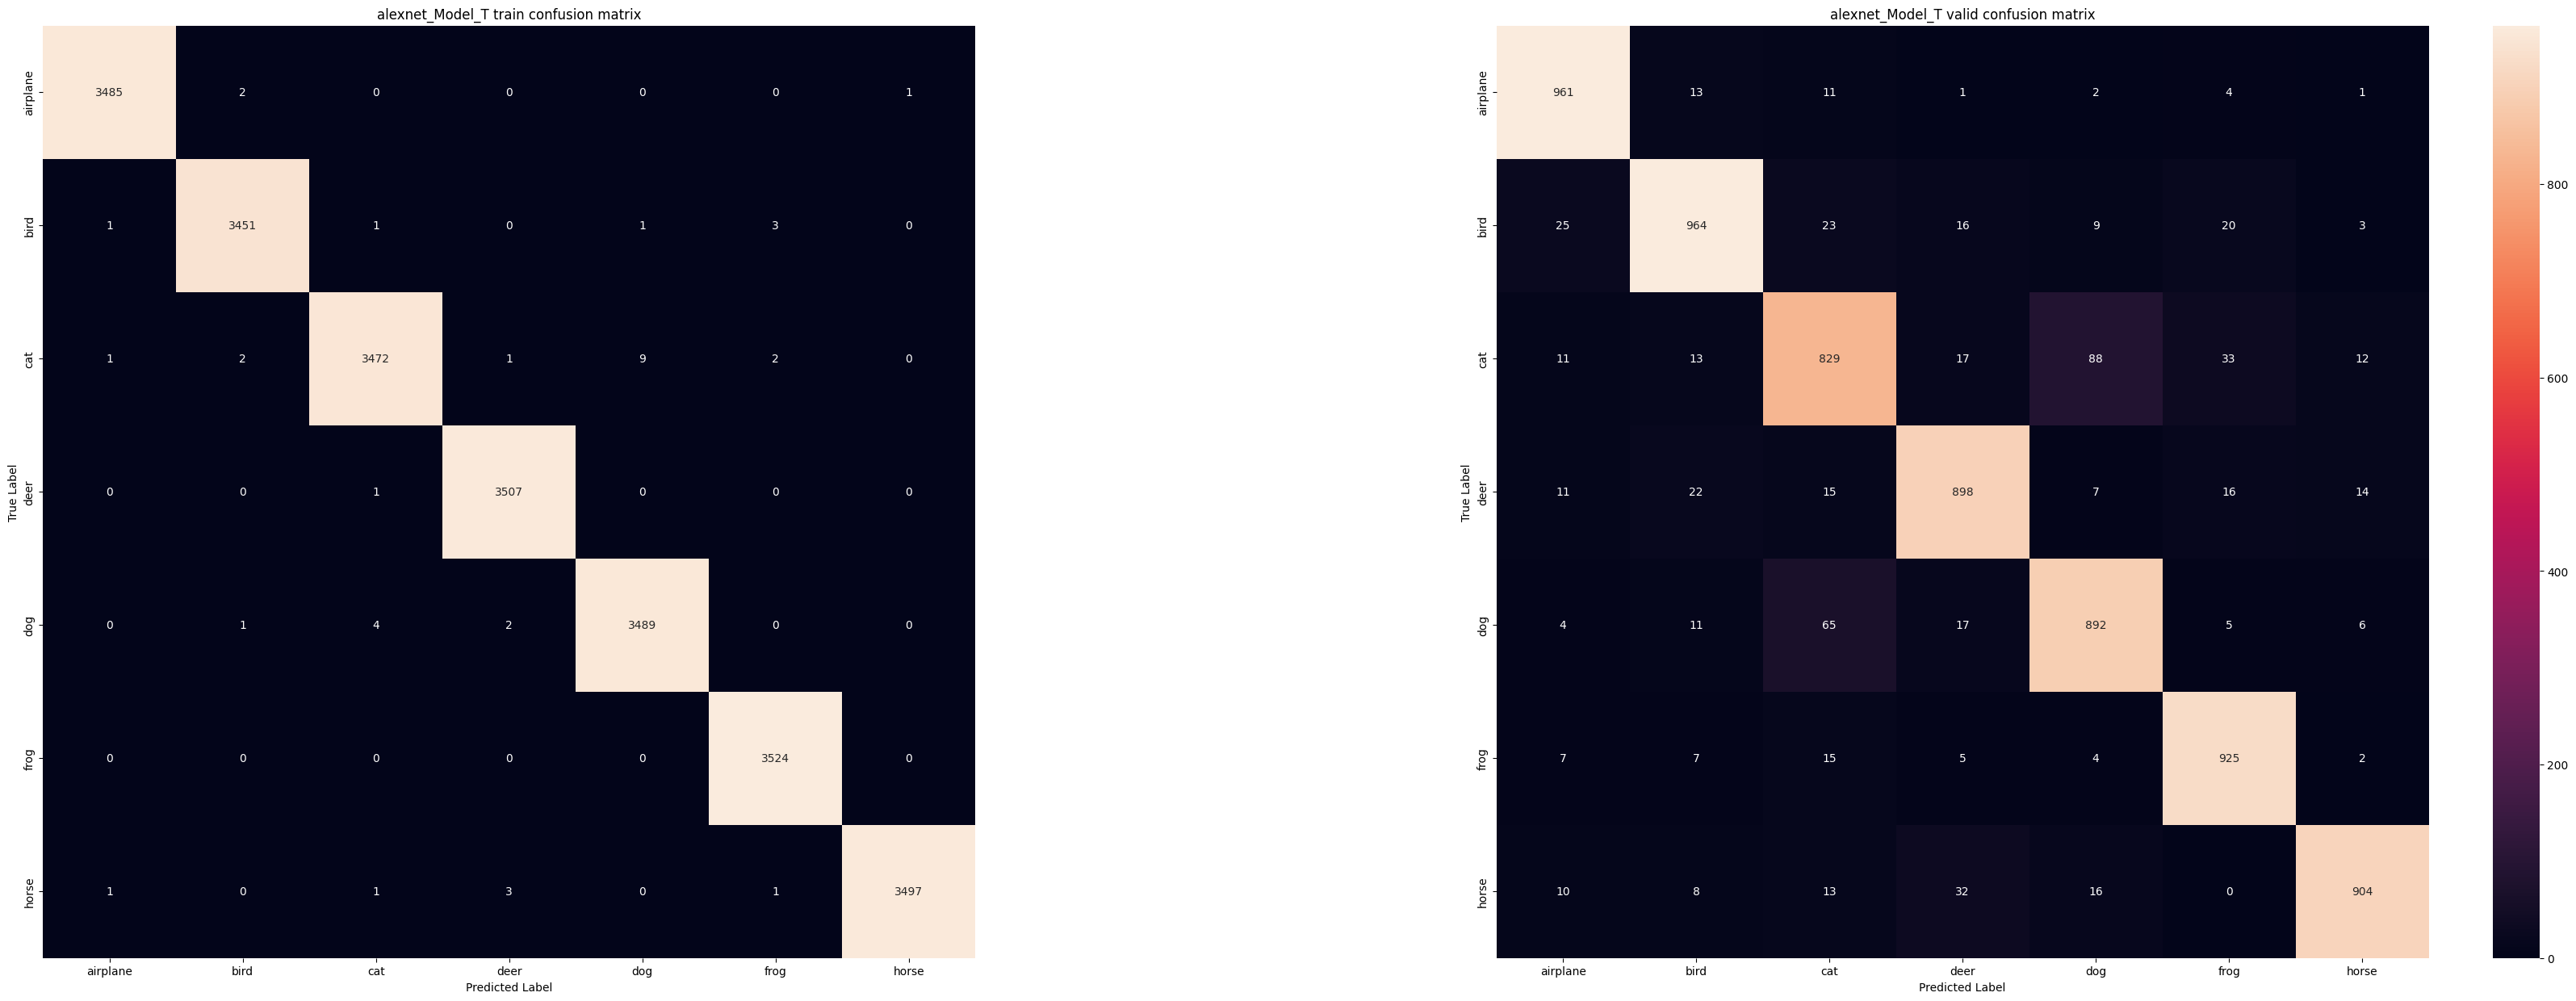

In [47]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

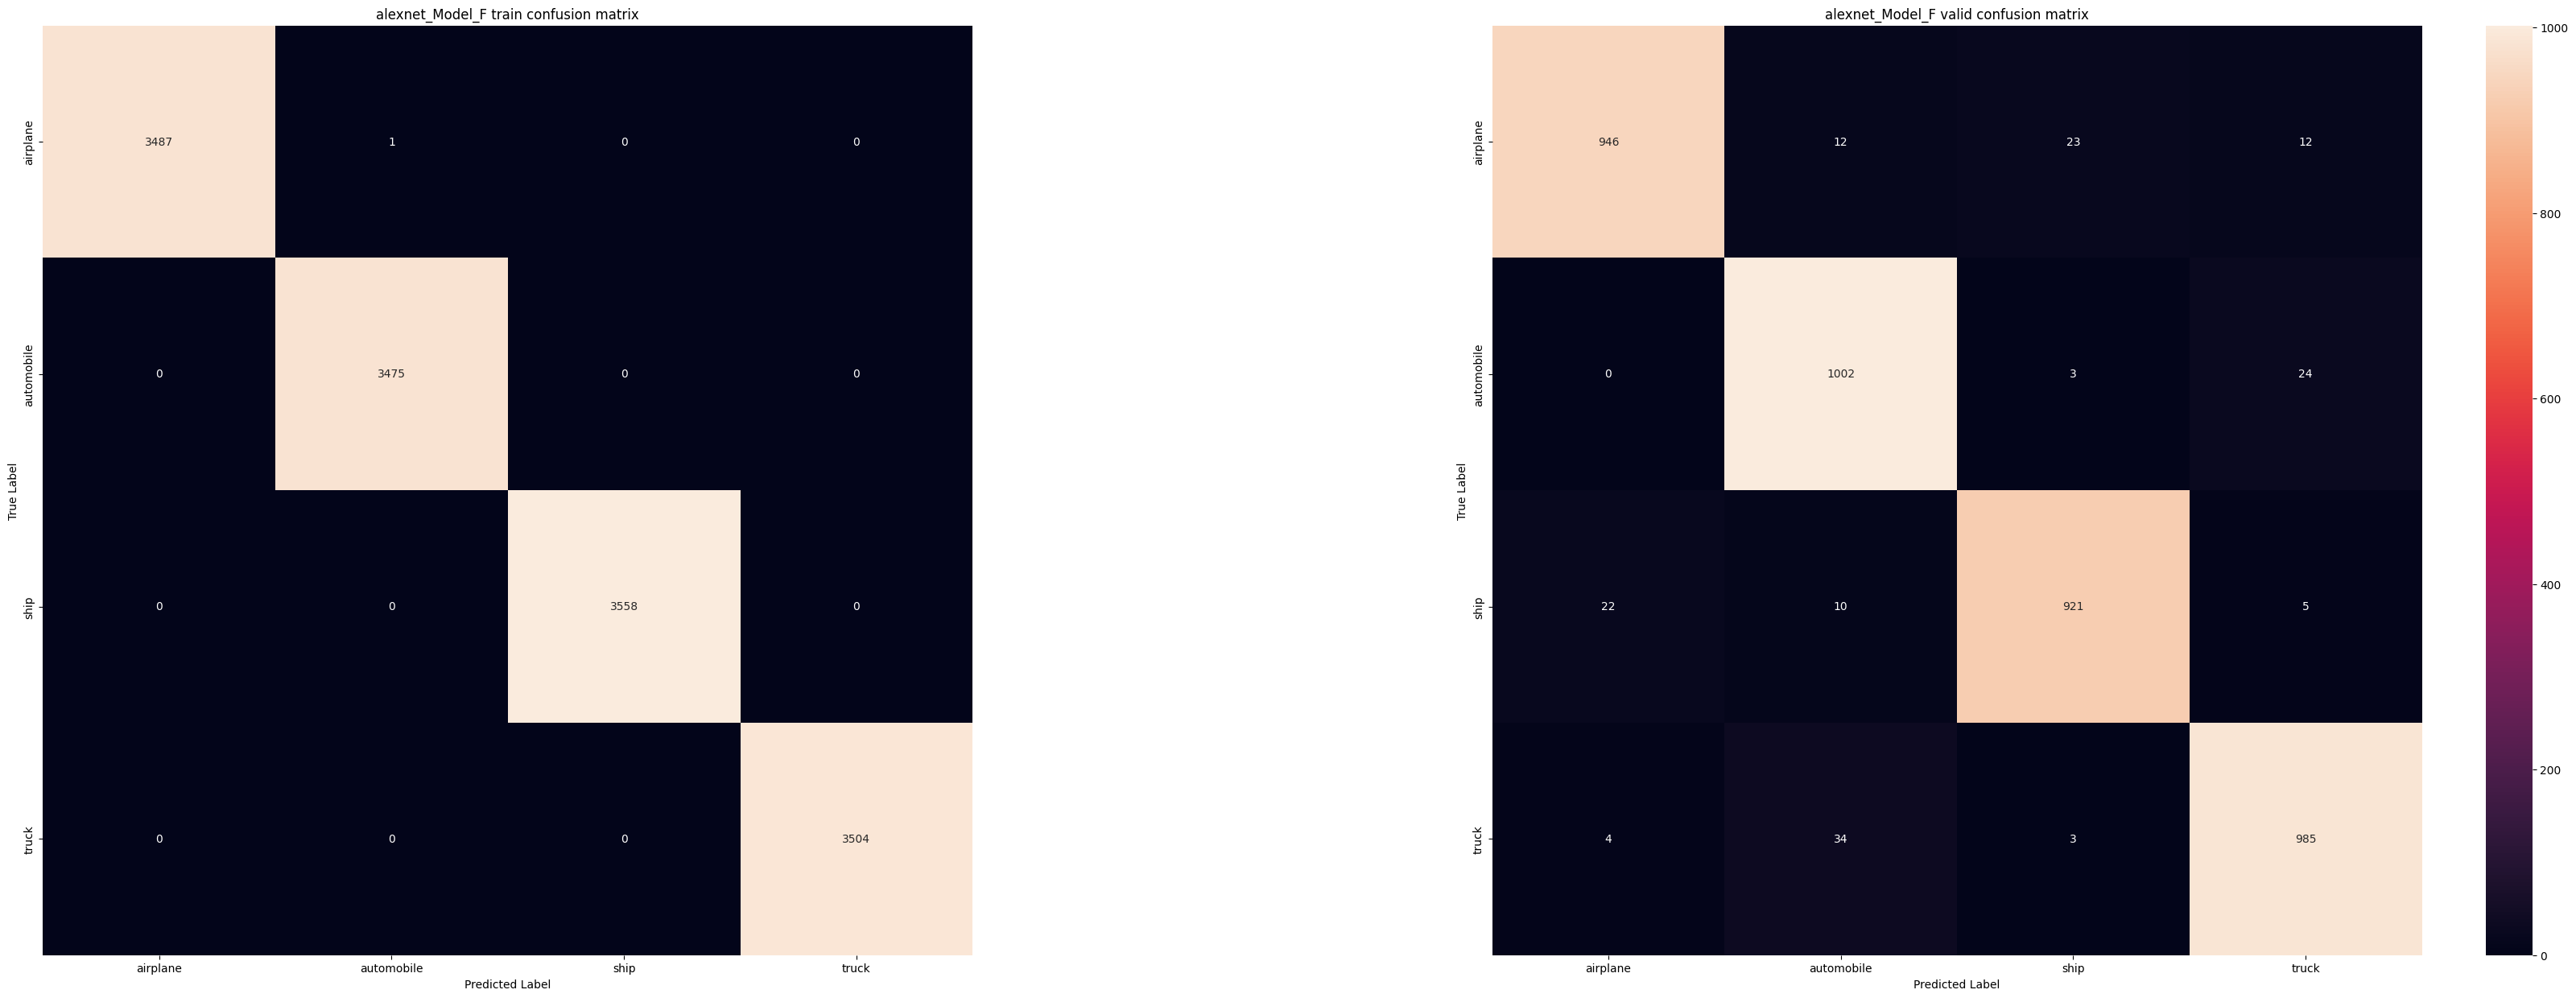

In [48]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [49]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [50]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,16275,1,1,0,1,1.000000,0.999966,1.000000,1.000000,True,False,True,False,False
1,35351,6,8,6,6,0.600808,1.000000,0.999914,1.000000,False,True,True,True,True
2,7367,3,1,3,3,0.828821,0.999406,0.971792,1.000000,False,True,True,True,True
3,20036,6,8,6,6,0.763633,0.999933,0.965352,1.000000,False,True,True,True,True
4,1641,2,1,2,2,0.999978,1.000000,1.000000,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,30535,0,0,0,0,1.000000,1.000000,0.999991,0.870257,True,True,True,True,False
34996,48982,9,9,0,9,1.000000,0.876728,0.997376,1.000000,True,False,True,False,False
34997,5458,5,1,5,5,0.571484,1.000000,0.999999,1.000000,False,True,True,True,True
34998,33366,6,1,6,6,0.808363,0.999997,0.999782,1.000000,False,True,True,True,True


In [51]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
19,15661,0,0,0,0,1.000000,1.000000,0.990192,0.731274,True,True,True,True,False
21,4940,0,0,0,0,1.000000,1.000000,0.999996,0.996790,True,True,True,True,False
30,1473,0,0,0,0,0.999979,0.999990,0.723173,0.843818,True,True,True,True,False
36,15866,0,0,0,0,1.000000,1.000000,1.000000,0.949571,True,True,True,True,False
41,2773,0,0,0,0,1.000000,0.999196,0.985799,0.985043,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34941,1142,0,0,0,0,1.000000,1.000000,0.685789,0.996822,True,True,True,True,False
34949,36819,0,0,0,0,1.000000,1.000000,0.999972,0.963776,True,True,True,True,False
34983,35430,0,0,0,0,1.000000,1.000000,1.000000,0.999910,True,True,True,True,False
34989,46945,0,0,0,0,1.000000,1.000000,0.999988,1.000000,True,True,True,True,False


In [52]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

0    1938
8       5
3       5
9       3
7       3
6       2
2       2
1       1
5       1
Name: Target, dtype: int64

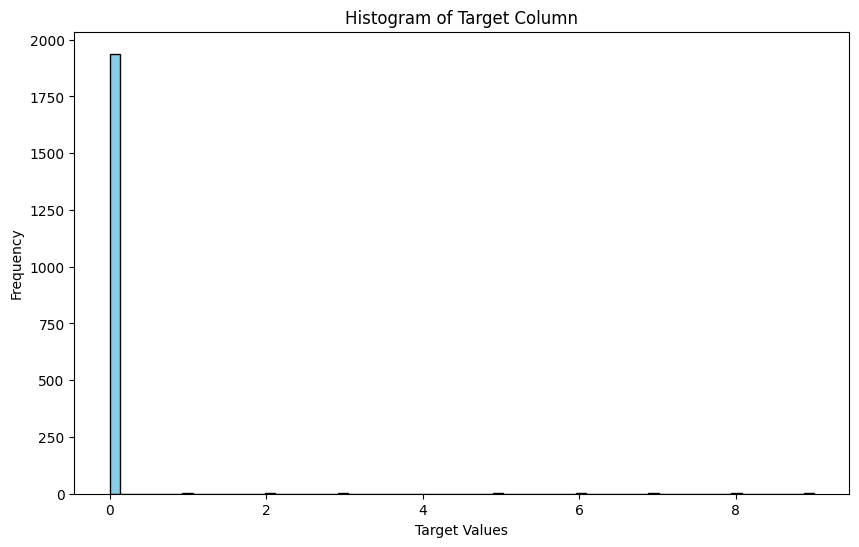

In [53]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [54]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

107

In [55]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

2

In [56]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
19,15661,0,0,0,0,1.000000,1.000000,0.990192,0.731274,True,True,True,True,False
30,1473,0,0,0,0,0.999979,0.999990,0.723173,0.843818,True,True,True,True,False
42,16346,0,0,0,0,0.999994,0.999756,0.982544,0.785456,True,True,True,True,False
90,25599,0,0,0,0,1.000000,1.000000,0.999766,0.677354,True,True,True,True,False
174,189,0,0,0,0,0.999845,0.984783,0.991231,0.861528,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34534,17084,0,0,0,0,1.000000,1.000000,0.999558,0.692355,True,True,True,True,False
34740,29145,5,0,0,0,0.984634,0.545162,0.504021,0.687661,False,False,False,False,True
34825,47931,0,0,0,0,1.000000,1.000000,1.000000,0.841901,True,True,True,True,False
34832,36231,0,0,0,0,1.000000,1.000000,0.999997,0.546323,True,True,True,True,False


In [57]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,23252,4,8,4,4,0.883799,1.000000,0.999999,1.000000,False,True,True,True,True
1,2054,5,9,5,5,0.942883,1.000000,0.999953,1.000000,False,True,True,True,True
2,25913,6,1,6,6,0.440936,0.999998,0.988534,1.000000,False,True,True,True,True
3,393,1,9,0,1,0.995658,1.000000,0.508091,1.000000,False,False,True,False,False
4,3548,0,0,0,0,1.000000,1.000000,0.999999,0.998872,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,16200,4,0,4,4,0.999999,0.993406,0.964141,1.000000,False,True,True,True,True
9996,29850,8,8,3,8,1.000000,0.916741,1.000000,1.000000,True,False,True,False,False
9997,11549,9,9,0,9,1.000000,0.999522,1.000000,1.000000,True,False,True,False,False
9998,21891,7,0,7,7,0.660980,1.000000,0.999895,1.000000,False,True,True,True,True


In [58]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

33

In [59]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

2

In [60]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
4,3548,0,0,0,0,1.000000,1.000000,0.999999,0.998872,True,True,True,True,False
32,30597,0,0,0,0,0.999974,1.000000,0.963045,0.999950,True,True,True,True,False
53,3093,8,8,5,8,0.999959,0.849188,0.944207,0.999182,True,False,True,True,False
73,6013,0,0,0,0,1.000000,1.000000,1.000000,0.970490,True,True,True,True,False
77,18386,0,0,0,0,1.000000,0.999587,0.765348,1.000000,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9883,43659,0,0,0,0,1.000000,1.000000,0.999920,0.999986,True,True,True,True,False
9906,17469,7,9,7,9,1.000000,1.000000,0.998841,1.000000,False,True,False,False,True
9962,32661,0,0,0,0,1.000000,0.999978,0.999915,1.000000,True,True,True,True,False
9968,49339,0,0,0,0,1.000000,1.000000,0.999993,0.811984,True,True,True,True,False


In [61]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

0    540
3     15
8     14
9     10
2      7
1      5
6      5
7      4
4      3
5      1
Name: Target, dtype: int64

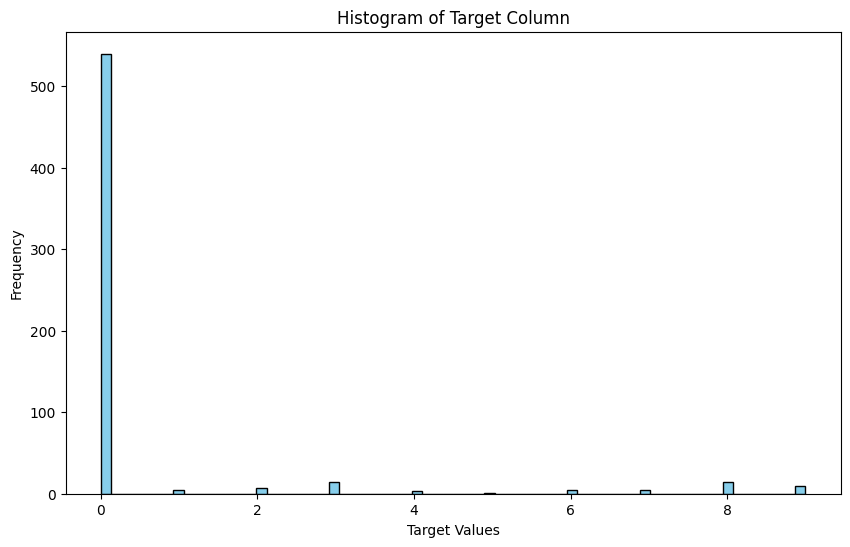

In [62]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [63]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (abs(df_results_v['Softmax_F']-df_results_v['Softmax_T'])>0.2)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
403,16004,0,0,0,0,1.000000,0.620609,0.624876,0.999995,True,True,True,True,False
605,37181,0,0,5,4,1.000000,0.453805,0.864034,1.000000,True,False,False,True,False
880,7083,8,1,3,3,0.992080,0.736603,0.770493,0.968704,False,False,False,True,False
980,10361,8,8,7,7,0.978920,0.609263,0.614509,0.961053,True,False,False,True,False
984,12659,0,0,0,0,1.000000,0.775305,0.926085,1.000000,True,True,True,True,False
1043,26081,0,0,0,3,0.999867,0.540489,0.875864,0.999999,True,True,False,True,False
1316,19055,9,0,0,6,0.665472,0.959696,0.478276,0.594477,False,False,False,True,False
1698,41274,0,0,2,2,0.999994,0.607081,0.516396,1.000000,True,False,False,True,False
1904,19099,3,8,3,8,0.998247,0.658255,0.396549,0.999150,False,True,False,False,True
2077,27204,2,8,0,8,0.784818,0.985771,0.826597,0.916311,False,False,False,False,True


In [64]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
4,3548,0,0,0,0,1.000000,1.000000,0.999999,0.998872,True,True,True,True,False
32,30597,0,0,0,0,0.999974,1.000000,0.963045,0.999950,True,True,True,True,False
53,3093,8,8,5,8,0.999959,0.849188,0.944207,0.999182,True,False,True,True,False
73,6013,0,0,0,0,1.000000,1.000000,1.000000,0.970490,True,True,True,True,False
77,18386,0,0,0,0,1.000000,0.999587,0.765348,1.000000,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9883,43659,0,0,0,0,1.000000,1.000000,0.999920,0.999986,True,True,True,True,False
9906,17469,7,9,7,9,1.000000,1.000000,0.998841,1.000000,False,True,False,False,True
9962,32661,0,0,0,0,1.000000,0.999978,0.999915,1.000000,True,True,True,True,False
9968,49339,0,0,0,0,1.000000,1.000000,0.999993,0.811984,True,True,True,True,False


In [65]:
# #全部模型裝在一起的表現
# def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
#     total_loss = 0
#     accu = 0
#     flat_true=[]
#     flat_pred=[]
#     sum_F=0
#     sum_T=0
#     with torch.no_grad():
#         for data,target,idx in data_dl:
#             outputs=[]
#             data,target=data.to(device),target.to(device)
#             out_growth = model_0(data)
#             softmax_0=torch.softmax(out_growth, dim=1)

#             out_T = model_T(data)
#             softmax_T=torch.softmax(out_T, dim=1)

#             out_F = model_F(data)
#             softmax_F=torch.softmax(out_F, dim=1)

         
            
#             for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
#                 st_max=torch.max(st).item()
#                 sf_max=torch.max(sf).item()

#                 out_decision=model_decision(d.unsqueeze(0))
#                 _, pred = torch.max(out_decision, dim = 1) 
#                 softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
#                 if(softmax_decision<0.9):
#                     # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
#                     # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
#                     if(sf_max>st_max):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1
#                 else:
                   
#                     if(pred==0):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1

#             outputs = torch.cat(outputs, dim=0)
#             _, y_pred_tag = torch.max(outputs, dim = 1)
#             loss = criterion(outputs, target)


#             flat_true.extend(target.cpu().numpy())
#             flat_pred.extend(y_pred_tag.cpu().numpy())

#             total_loss+= loss.item()*data.size(0)
#             correct=torch.sum(y_pred_tag == target).item()
#             accu += correct      

#     total_loss=total_loss/size
#     accu=accu/size
#     idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
#     confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
#     return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [66]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [67]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.03749371310379647, 0.9974857142857143, 12117, 22883)

In [68]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.8163284599871841, 0.9126, 3632, 6368)

In [69]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score
#模型表現
def evaluate_metric_model(model,data_dl,size,data_name,mode=None):
        
        model.to(device)
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   
            for data, target,idx in data_dl:
                    
                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)

                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        # 计算各种指标
        precision = precision_score(flat_true, flat_pred, average='macro')
        recall = recall_score(flat_true, flat_pred, average='macro')
        f1 = f1_score(flat_true, flat_pred, average='macro')
        

        a=sorted(set(flat_true))
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu,precision,recall,f1

In [70]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.042634448802045415,
 0.9872571428571428,
 0.9872954399933992,
 0.9872378113221991,
 0.9872347756515557)

In [71]:
evaluate_metric_model(model_0,valid_dl,valid_size,"0",mode=None)

(0.2984408666551113,
 0.9122,
 0.912436495272192,
 0.9124747208669749,
 0.9121150058385121)

In [72]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.04196157408138471,
 0.9876857142857143,
 0.9877258016018395,
 0.9876662919131117,
 0.9876694764520968)